# Proyecto Integrador - Arquitectura Híbrida de Bases de Datos para Ecommify
# Etapa 1: Hoja formativa

## Objetivo
Diseñar e implementar una arquitectura híbrida de bases de datos para la plataforma Ecommify utilizando el dataset Brazilian E-commerce (Olist).

## Dataset utilizado
Brazilian E-commerce Public Dataset by Olist:
https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

## Integrantes
- Nicolás Cifuentes Barriga
- Andres Camilo Meneses Ortega
- David Hernando Monsalve Delima
- Eduardo Trujillo Santos

## Tecnologías utilizadas
- Google Colab
- Python
- Pandas
- Matplotlib
- Seaborn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
path = "/content/drive/MyDrive/Maestrias/Arquitectura de software - sabana/Semestre 1/Optimización de dB/"

In [4]:
customers = pd.read_csv(path + "olist_customers_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
order_payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
orders = pd.read_csv(path + "olist_orders_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
category = pd.read_csv(path + "product_category_name_translation.csv")

In [5]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category": category
}

In [6]:
# Crear lista con información
summary = []

for name, df in datasets.items():
    summary.append({
        "Tabla": name,
        "Número de columnas": len(df.columns),
        "Columnas": ", ".join(df.columns)
    })

# Convertir a DataFrame
summary_df = pd.DataFrame(summary)

# Mostrar tabla
summary_df

,Tabla,Número de columnas,Columnas
0,customers,5,"customer_id, customer_unique_id, customer_zip_..."
1,geolocation,5,"geolocation_zip_code_prefix, geolocation_lat, ..."
2,order_items,7,"order_id, order_item_id, product_id, seller_id..."
3,order_payments,5,"order_id, payment_sequential, payment_type, pa..."
4,order_reviews,7,"review_id, order_id, review_score, review_comm..."
5,orders,8,"order_id, customer_id, order_status, order_pur..."
6,products,9,"product_id, product_category_name, product_nam..."
7,sellers,4,"seller_id, seller_zip_code_prefix, seller_city..."
8,category,2,"product_category_name, product_category_name_e..."


## Join Ordersfull - dB denormalizada

In [7]:
# =========================
# JOIN PRINCIPAL
# =========================

orders_full = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

orders_full = orders_full.merge(
    order_items,
    on='order_id',
    how='left'
)

orders_full = orders_full.merge(
    products,
    on='product_id',
    how='left'
)

orders_full = orders_full.merge(
    sellers,
    on='seller_id',
    how='left'
)

orders_full = orders_full.merge(
    order_payments,
    on='order_id',
    how='left'
)

orders_full = orders_full.merge(
    order_reviews,
    on='order_id',
    how='left'
)

orders_full = orders_full.merge(
    category,
    on='product_category_name',
    how='left'
)

# Mostrar dimensiones finales
print("Dimensiones OrdersFull:")
print(orders_full.shape)

# Mostrar primeras filas
orders_full.head()

Dimensiones OrdersFull:
(119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


## Relaciones identificadas

| Tabla principal | Relación              | Tabla secundaria |
| --------------- | --------------------- | ---------------- |
| orders          | customer_id           | customers        |
| order_items     | order_id              | orders           |
| order_items     | product_id            | products         |
| order_items     | seller_id             | sellers          |
| order_payments  | order_id              | orders           |
| order_reviews   | order_id              | orders           |
| products        | product_category_name | category         |

## Análisis de nulos

In [8]:
null_summary = []

for name, df in datasets.items():

    # Total de valores nulos
    total_nulls = df.isnull().sum().sum()

    # Porcentaje de nulos respecto al total de celdas
    total_cells = df.shape[0] * df.shape[1]
    null_percentage = (total_nulls / total_cells) * 100

    # Columnas con nulos
    null_columns = df.columns[df.isnull().any()].tolist()

    null_summary.append({
        "Tabla": name,
        "Filas": df.shape[0],
        "Columnas": df.shape[1],
        "Valores nulos": total_nulls,
        "% nulos": round(null_percentage, 2),
        "Columnas con nulos": ", ".join(null_columns) if null_columns else "Sin nulos"
    })

# Convertir a DataFrame
null_summary_df = pd.DataFrame(null_summary)

# Mostrar resultados
null_summary_df

,Tabla,Filas,Columnas,Valores nulos,% nulos,Columnas con nulos
0,customers,99441,5,0,0.00,Sin nulos
1,geolocation,1000163,5,0,0.00,Sin nulos
2,order_items,112650,7,0,0.00,Sin nulos
3,order_payments,103886,5,0,0.00,Sin nulos
4,order_reviews,99224,7,145903,21.01,"review_comment_title, review_comment_message"
5,orders,99441,8,4908,0.62,"order_approved_at, order_delivered_carrier_dat..."
6,products,32951,9,2448,0.83,"product_category_name, product_name_lenght, pr..."
7,sellers,3095,4,0,0.00,Sin nulos
8,category,71,2,0,0.00,Sin nulos


##

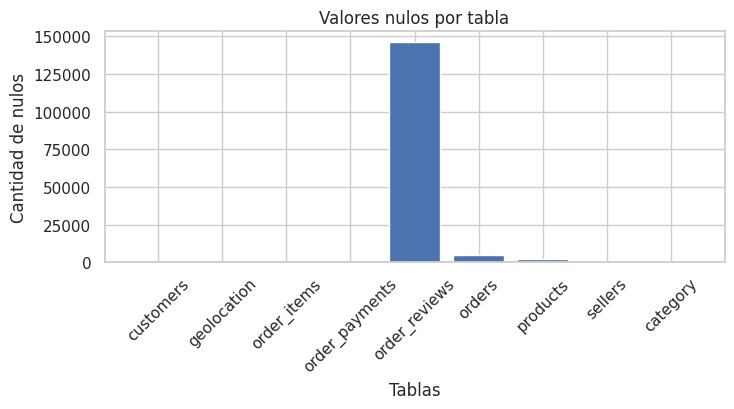

In [9]:
plt.figure(figsize=(8,3))

plt.bar(
    null_summary_df["Tabla"],
    null_summary_df["Valores nulos"]
)

plt.xticks(rotation=45)
plt.title("Valores nulos por tabla")
plt.xlabel("Tablas")
plt.ylabel("Cantidad de nulos")

plt.show()

## Analisis de calidad de datos

### Duplicidad

In [10]:
duplicated_summary = []

for name, df in datasets.items():

    # Total de filas duplicadas
    total_duplicated = df.duplicated().sum()

    # Porcentaje de duplicados respecto al total de filas
    duplicated_percentage = (
        total_duplicated / df.shape[0]
    ) * 100

    # Columnas que contienen valores repetidos
    duplicated_columns = []

    for col in df.columns:
        if df[col].duplicated().any():
            duplicated_columns.append(col)

    duplicated_summary.append({
        "Tabla": name,
        "Filas": df.shape[0],
        "Columnas": df.shape[1],
        "Filas duplicadas": total_duplicated,
        "% duplicados": round(duplicated_percentage, 2),
        "Columnas con valores repetidos":
            ", ".join(duplicated_columns)
            if duplicated_columns
            else "Sin duplicados"
    })

# Convertir a DataFrame
duplicated_summary_df = pd.DataFrame(duplicated_summary)

# Mostrar resultados
duplicated_summary_df

,Tabla,Filas,Columnas,Filas duplicadas,% duplicados,Columnas con valores repetidos
0,customers,99441,5,0,0.00,"customer_unique_id, customer_zip_code_prefix, ..."
1,geolocation,1000163,5,261831,26.18,"geolocation_zip_code_prefix, geolocation_lat, ..."
2,order_items,112650,7,0,0.00,"order_id, order_item_id, product_id, seller_id..."
3,order_payments,103886,5,0,0.00,"order_id, payment_sequential, payment_type, pa..."
4,order_reviews,99224,7,0,0.00,"review_id, order_id, review_score, review_comm..."
5,orders,99441,8,0,0.00,"order_status, order_purchase_timestamp, order_..."
6,products,32951,9,0,0.00,"product_category_name, product_name_lenght, pr..."
7,sellers,3095,4,0,0.00,"seller_zip_code_prefix, seller_city, seller_state"
8,category,71,2,0,0.00,Sin duplicados


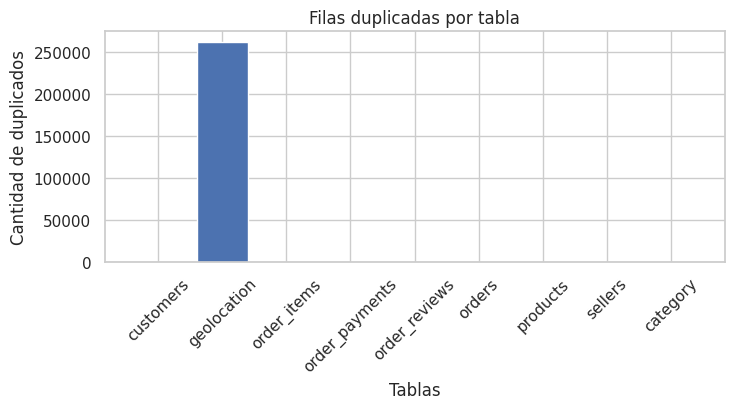

In [11]:
plt.figure(figsize=(8,3))

plt.bar(
    duplicated_summary_df["Tabla"],
    duplicated_summary_df["Filas duplicadas"]
)

plt.xticks(rotation=45)
plt.title("Filas duplicadas por tabla")
plt.xlabel("Tablas")
plt.ylabel("Cantidad de duplicados")

plt.show()

### Tipos de datos

In [12]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [13]:
dtype_detail = []

for name, df in datasets.items():

    for column in df.columns:

        dtype_detail.append({
            "Tabla": name,
            "Columna": column,
            "Tipo de dato": str(df[column].dtype)
        })

# Convertir a DataFrame
dtype_detail_df = pd.DataFrame(dtype_detail)

# Mostrar resultados
dtype_detail_df

,Tabla,Columna,Tipo de dato
0,customers,customer_id,object
1,customers,customer_unique_id,object
2,customers,customer_zip_code_prefix,int64
3,customers,customer_city,object
4,customers,customer_state,object
5,geolocation,geolocation_zip_code_prefix,int64
6,geolocation,geolocation_lat,float64
7,geolocation,geolocation_lng,float64
8,geolocation,geolocation_city,object
9,geolocation,geolocation_state,object


### Valores unicos, cardinalidad

In [14]:
nunique_detail = []

for name, df in datasets.items():

    for column in df.columns:

        nunique_detail.append({
            "Tabla": name,
            "Columna": column,
            "Valores únicos": df[column].nunique(),
            "Tipo de dato": str(df[column].dtype)
        })

# Convertir a DataFrame
nunique_detail_df = pd.DataFrame(nunique_detail)

nunique_detail_df_sort = nunique_detail_df.sort_values(
    by="Valores únicos",
    ascending=False
)

nunique_detail_df_sort

,Tabla,Columna,Valores únicos,Tipo de dato
7,geolocation,geolocation_lng,717613,float64
6,geolocation,geolocation_lat,717360,float64
0,customers,customer_id,99441,object
30,orders,customer_id,99441,object
29,orders,order_id,99441,object
17,order_payments,order_id,99440,object
32,orders,order_purchase_timestamp,98875,datetime64[ns]
23,order_reviews,order_id,98673,object
10,order_items,order_id,98666,object
22,order_reviews,review_id,98410,object


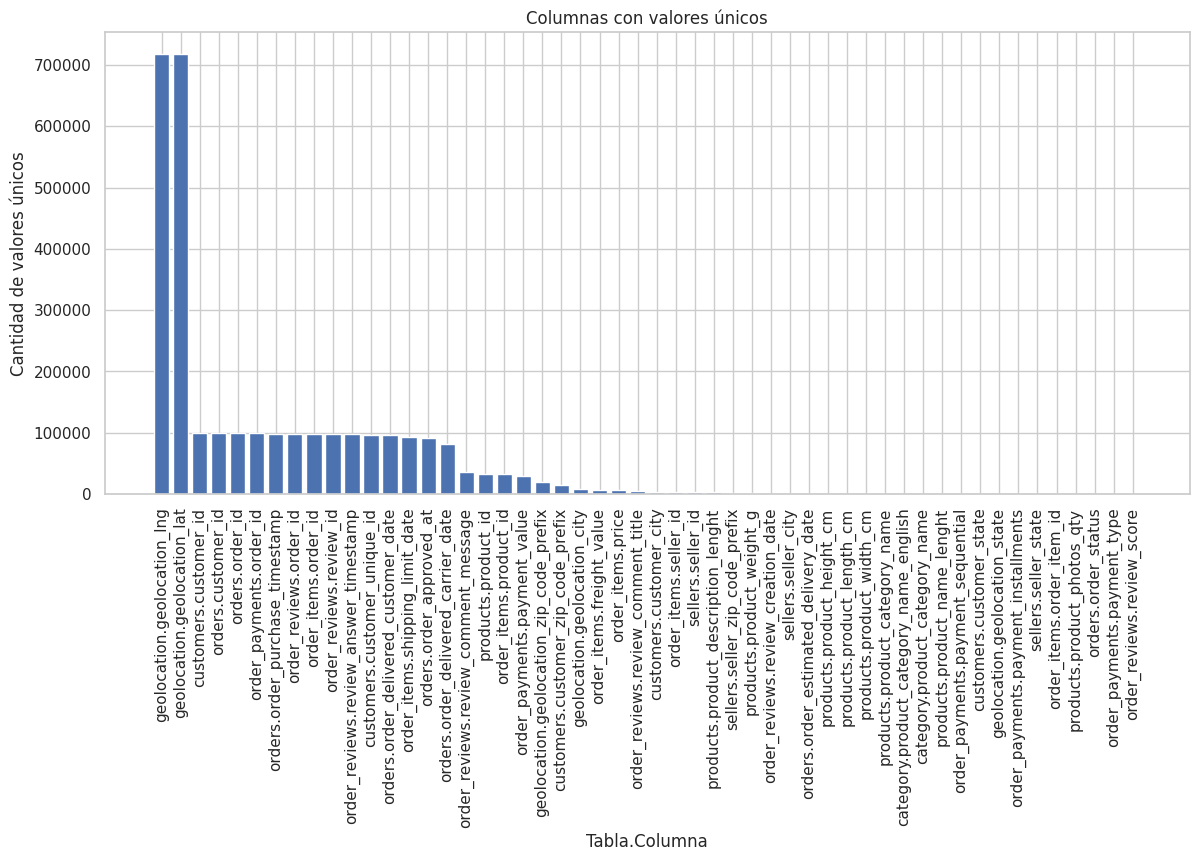

In [15]:
# Convertir a numérico
nunique_detail_df["Valores únicos"] = pd.to_numeric(
    nunique_detail_df["Valores únicos"],
    errors='coerce'
)

# Filtrar solo valores mayores a 0
filtered_nunique = nunique_detail_df[
    nunique_detail_df["Valores únicos"] > 0
]

# Ordenar
top_unique = filtered_nunique.sort_values(
    by="Valores únicos",
    ascending=False
)

# Crear gráfica
plt.figure(figsize=(14,6))

plt.bar(
    top_unique["Tabla"] + "." + top_unique["Columna"],
    top_unique["Valores únicos"]
)

plt.xticks(rotation=90)
plt.title("Columnas con valores únicos")
plt.xlabel("Tabla.Columna")
plt.ylabel("Cantidad de valores únicos")

plt.show()

## Distribucion temporal y geografica

### Pedidos por mes

In [16]:
orders_full['order_purchase_timestamp'] = pd.to_datetime(
    orders_full['order_purchase_timestamp']
)

orders_full['year_month'] = (
    orders_full['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

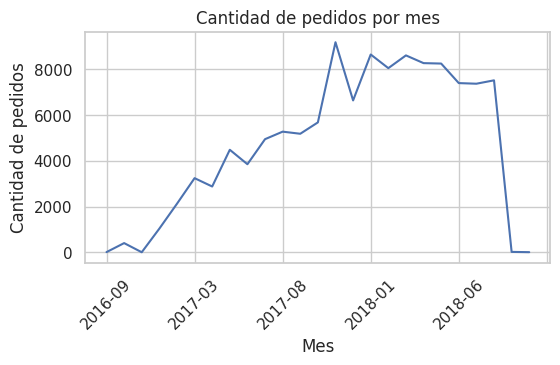

In [17]:
monthly_orders = orders_full.groupby(
    'year_month'
).size()

plt.figure(figsize=(6,3))

monthly_orders.plot()

plt.title("Cantidad de pedidos por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=45)

plt.show()

### Pedidos por semana

In [18]:
orders_full['day_of_week'] = (
    orders_full['order_purchase_timestamp']
    .dt.day_name()
)

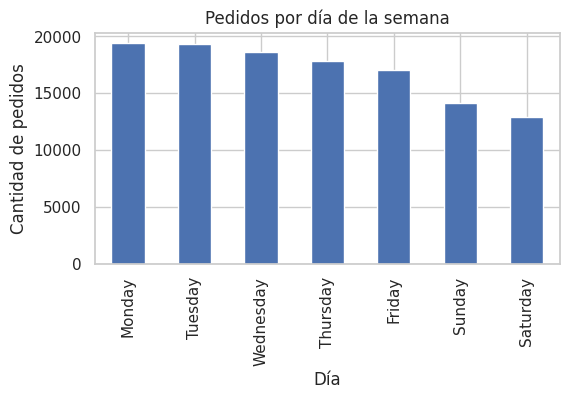

In [19]:
day_orders = orders_full['day_of_week'].value_counts()

plt.figure(figsize=(6,3))

day_orders.plot(kind='bar')

plt.title("Pedidos por día de la semana")
plt.xlabel("Día")
plt.ylabel("Cantidad de pedidos")

plt.show()

### Pedidos por hora

In [20]:
orders_full['hour'] = (
    orders_full['order_purchase_timestamp']
    .dt.hour
)

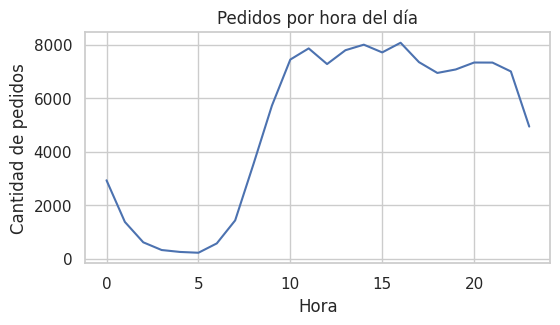

In [21]:
hour_orders = orders_full['hour'].value_counts().sort_index()

plt.figure(figsize=(6,3))

hour_orders.plot(kind='line')

plt.title("Pedidos por hora del día")
plt.xlabel("Hora")
plt.ylabel("Cantidad de pedidos")

plt.show()

### Pedidos por estados

In [22]:
state_orders = orders_full[
    'customer_state'
].value_counts().head(10)

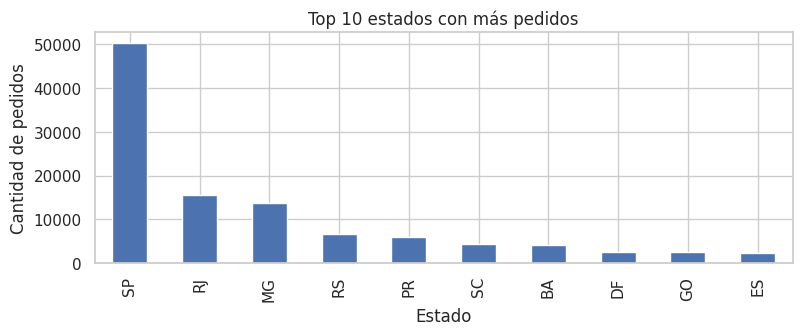

In [23]:
plt.figure(figsize=(9,3))

state_orders.plot(kind='bar')

plt.title("Top 10 estados con más pedidos")
plt.xlabel("Estado")
plt.ylabel("Cantidad de pedidos")

plt.show()

### Pedidos por ciudades

In [24]:
top_cities = orders_full[
    'customer_city'
].value_counts().head(10)

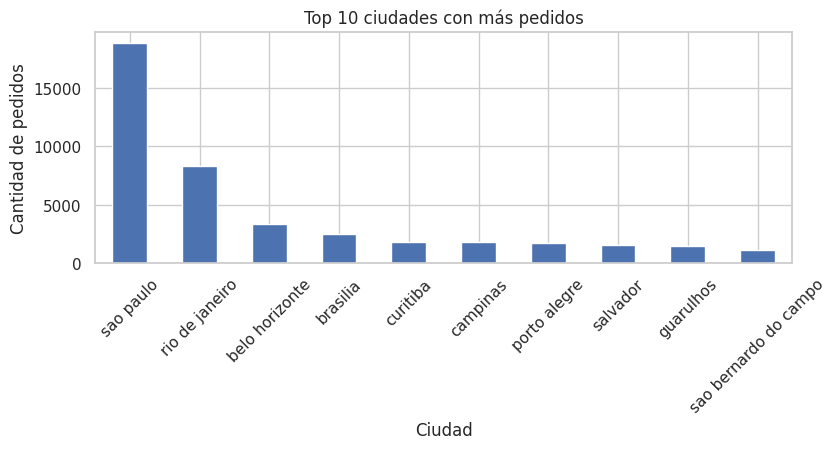

In [25]:
plt.figure(figsize=(9,3))

top_cities.plot(kind='bar')

plt.title("Top 10 ciudades con más pedidos")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de pedidos")

plt.xticks(rotation=45)

plt.show()

### Mapa con coordenadas

In [26]:
geo_orders = customers.merge(
    geolocation,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

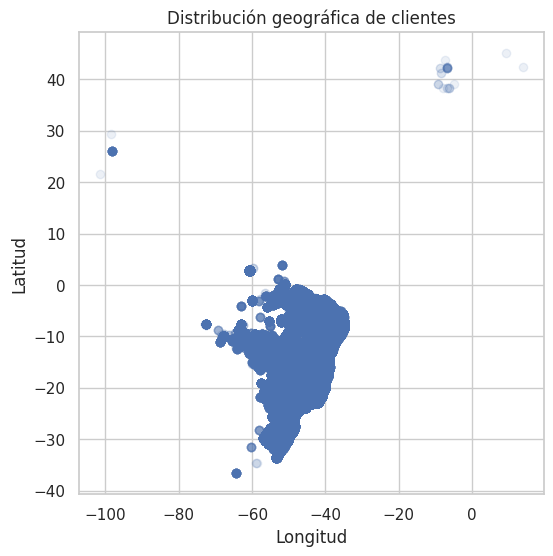

In [27]:
plt.figure(figsize=(6,6))

plt.scatter(
    geo_orders['geolocation_lng'],
    geo_orders['geolocation_lat'],
    alpha=0.1
)

plt.title("Distribución geográfica de clientes")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

### Mapa de correlación

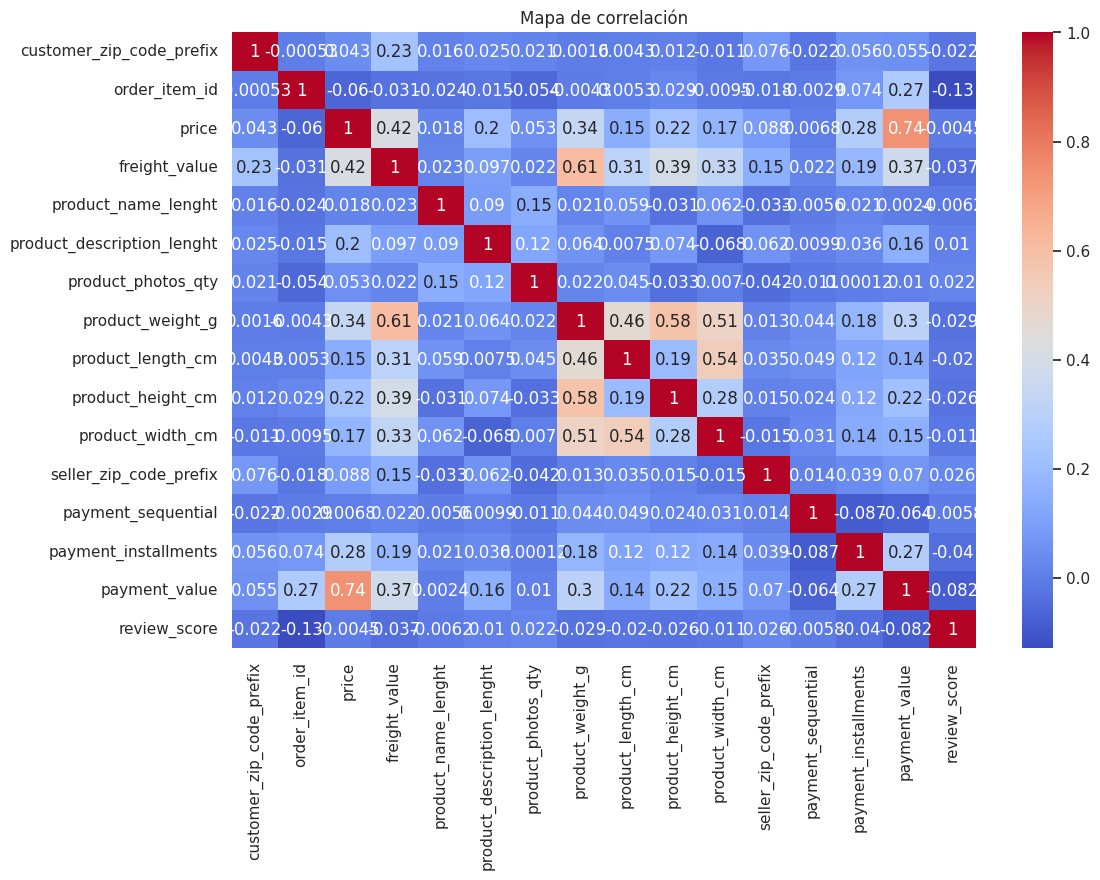

In [28]:
numeric_columns = orders_full.select_dtypes(
    include=['int64', 'float64']
)

correlation = numeric_columns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Mapa de correlación")

plt.show()